<a href="https://colab.research.google.com/github/heyanugrah/CNNronaldoMessiClassification/blob/main/Copy_of_Project_rono.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt


In [ ]:
# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu


In [ ]:
class PlayerClassificationModel(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_4 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*4*4, # Corrected based on 64x64 input -> 4x4 after four MaxPool2d layers
                      out_features=output_shape)
        )
  def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.classifier(x)
        return x

In [ ]:

model = PlayerClassificationModel(input_shape=3,
                                  hidden_units=100,
                                  output_shape=2)


In [ ]:
model

PlayerClassificationModel(
  (block_1): Sequential(
    (0): Conv2d(3, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(100, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(100, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(100, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(100, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(100, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_4): Sequential(
    (0): Conv2d(100, 100, kernel_size=(3, 3), stride=

In [ ]:
import os
import zipfile
from pathlib import Path

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive.zip'
extract_dir = '/content/'

# Ensure the extraction directory exists
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file. Please ensure the file is not corrupted.")
except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

'/content/archive.zip' unzipped to '/content/' successfully.


In [ ]:
data_dir = os.path.join(extract_dir, 'dataset')
print(f"Data directory set to: {data_dir}")

Data directory set to: /content/dataset


In [ ]:
import shutil

# Path to the .ipynb_checkpoints directory
checkpoint_dir = os.path.join(data_dir, '.ipynb_checkpoints')

# Check if the directory exists and remove it
if os.path.exists(checkpoint_dir) and os.path.isdir(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)
    print(f"Removed problematic directory: {checkpoint_dir}")
else:
    print(f"Directory not found or already removed: {checkpoint_dir}")

Directory not found or already removed: /content/dataset/.ipynb_checkpoints


In [ ]:
# Setup training data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for the images
data_transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize images to 64x64 pixels
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize image data
])

# Function to filter out .ipynb_checkpoints directories
def is_valid_file(path):
    return '.ipynb_checkpoints' not in path and not path.endswith('.DS_Store')

# Load the dataset using ImageFolder
# The root directory should contain subdirectories for each class (e.g., 'messi', 'ronaldo')
train_data = datasets.ImageFolder(root=data_dir,
                                  transform=data_transform,
                                  target_transform=None,
                                  is_valid_file=is_valid_file) # Filter out unwanted files/directories


In [ ]:
from torch.utils.data import random_split

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.5 * len(train_data))
test_size = len(train_data) - train_size

# Split the dataset
train_dataset, test_dataset = random_split(train_data, [train_size, test_size])

print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

Training dataset size: 229
Testing dataset size: 230


In [ ]:
# Setup the data loaders
# BATCH_SIZE is already defined in the kernel as 32, so we can directly use it.
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                            batch_size=BATCH_SIZE,
                            shuffle=False) # No need to shuffle validation data

print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in validation DataLoader: {len(test_dataloader)}")

Number of batches in training DataLoader: 8
Number of batches in validation DataLoader: 8


In [ ]:
# Demonstrate basic use of DataLoader
# Get one batch from the training dataloader
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch + 1}")
    print(f"  Features (X) shape: {X.shape}")
    print(f"  Labels (y) shape: {y.shape}")

    # Break after the first batch to just show one example
    break

print(f"\nClass to index mapping: {train_data.class_to_idx}")
print(f"Classes: {train_data.classes}")


Batch: 1
  Features (X) shape: torch.Size([32, 3, 64, 64])
  Labels (y) shape: torch.Size([32])

Class to index mapping: {'messi': 0, 'ronaldo': 1}
Classes: ['messi', 'ronaldo']


In [ ]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


from tqdm.auto import tqdm #for progress bar

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    model.train() # put model in train mode
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate accuracy
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    model.eval() # put model in eval mode
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

# Create empty results dictionary
results = {"train_loss": [],
           "train_acc": [],
           "test_loss": [],
           "test_acc": []
}

# Set the number of epochs
NUM_EPOCHS = 7

# Loop through training and testing steps for a number of epochs
for epoch in tqdm(range(NUM_EPOCHS)):
    train_loss, train_acc = train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device)
    test_loss, test_acc = test_step(model=model,
                                      dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      device=device)

    # Print out what's happening
    print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
    )

    # Update results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch: 1 | train_loss: 0.7004 | train_acc: 0.4891 | test_loss: 0.6931 | test_acc: 0.4987
Epoch: 2 | train_loss: 0.6926 | train_acc: 0.5164 | test_loss: 0.6943 | test_acc: 0.4727
Epoch: 3 | train_loss: 0.6903 | train_acc: 0.5320 | test_loss: 0.6974 | test_acc: 0.4727
Epoch: 4 | train_loss: 0.6812 | train_acc: 0.5320 | test_loss: 0.7590 | test_acc: 0.4727
Epoch: 5 | train_loss: 0.6962 | train_acc: 0.5281 | test_loss: 0.6896 | test_acc: 0.4844
Epoch: 6 | train_loss: 0.6717 | train_acc: 0.5727 | test_loss: 0.6739 | test_acc: 0.6029
Epoch: 7 | train_loss: 0.6774 | train_acc: 0.6188 | test_loss: 0.6224 | test_acc: 0.6862


## Visualizing Model Performance

Let's plot the training and testing loss and accuracy over epochs to get a better understanding of our model's performance and to check for overfitting or underfitting.

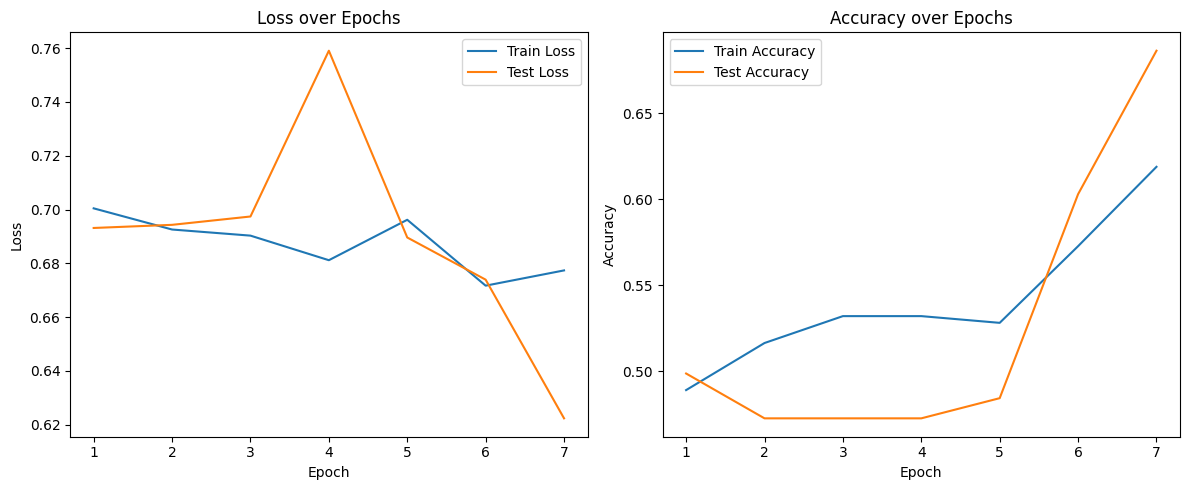

In [ ]:
import matplotlib.pyplot as plt

# Get the results from the dictionary
train_loss = results['train_loss']
train_acc = results['train_acc']
test_loss = results['test_loss']
test_acc = results['test_acc']

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, test_loss, label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, test_acc, label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install torchinfo
from torchinfo import summary

# Print a summary using torchinfo (uncomment for actual output)
summary(model=model,
        input_size=(32, 3, 64, 64), # Corrected input_size to match image transformations
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

ModuleNotFoundError: No module named 'torchinfo'

In [ ]:
from PIL import Image
import torchvision.transforms as transforms

def predict_image(image_path: str, model: torch.nn.Module, transform: transforms.Compose, class_names: list, device: torch.device):
    """
    Predicts the class of a single image using the trained model.

    Args:
        image_path (str): The path to the image file.
        model (torch.nn.Module): The trained PyTorch model.
        transform (transforms.Compose): The image transformations to apply.
        class_names (list): A list of class names (e.g., ['messi', 'ronaldo']).
        device (torch.device): The device (CPU or GPU) to run inference on.

    Returns:
        str: The predicted class label.
    """
    # Load the image
    img = Image.open(image_path)

    # Preprocess the image
    transformed_img = transform(img).unsqueeze(0).to(device) # Add batch dimension and move to device

    # Put model in evaluation mode
    model.eval()

    with torch.inference_mode():
        # Make a prediction
        pred_logits = model(transformed_img)

        # Convert logits to prediction probabilities
        pred_prob = torch.softmax(pred_logits, dim=1)

        # Get the predicted class index
        pred_idx = torch.argmax(pred_prob, dim=1).item()

        # Get the predicted class name
        predicted_class = class_names[pred_idx]

    print(f"Image: {image_path}")
    print(f"Predicted class: {predicted_class}")
    print(f"Prediction probabilities: {pred_prob.cpu().numpy()[0]}")

    return predicted_class

# Get class names from the training dataset for interpretation
# Assuming train_data is available from previous cells
class_names = train_data.classes

# Example usage:
# You can change this path to any image you want to test
example_image_path = '/content/predictions/mr7.jpg' # Example image from the dataset

# Ensure model and data_transform are available from previous cells
# model, data_transform, device

predicted_class = predict_image(image_path=example_image_path,
                                model=model,
                                transform=data_transform,
                                class_names=class_names,
                                device=device)


Image: /content/predictions/mr7.jpg
Predicted class: messi
Prediction probabilities: [0.56501925 0.43498078]
